# Stage 5: Causal Meta-Learners

This notebook trains and evaluates two heterogeneous treatment-effect models:

- S-learner
- T-learner

Unlike a churn model, these models estimate how receiving the retention offer
changes each customer's probability of remaining subscribed.

The simulator's oracle columns are used only for evaluation. They are never
provided to the learners during training.

In [1]:
from pathlib import Path
import os
import sys

# Start Jupyter from the repository/notebooks directory, or explicitly set
# CAUSAL_INFERENCE_ROOT when the kernel starts elsewhere.
configured_root = os.environ.get("CAUSAL_INFERENCE_ROOT")
current_directory = Path.cwd().resolve()
candidates = (
    [Path(configured_root).expanduser().resolve()]
    if configured_root
    else [current_directory, *current_directory.parents]
)
PROJECT_ROOT = next(
    (
        candidate for candidate in candidates
        if all(
            (candidate / "src" / filename).is_file()
            for filename in ("causal_learners.py", "policies.py", "simulation.py")
        )
        and (candidate / "notebooks" / "03_causal_meta_learners.ipynb").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Cannot locate the Causal_Inference repository. Start Jupyter from "
        "the project or notebooks directory, or set CAUSAL_INFERENCE_ROOT "
        "to the repository path before running this notebook."
    )

SRC_DIRECTORY = PROJECT_ROOT / "src"
if str(SRC_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SRC_DIRECTORY))


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from causal_learners import (
    MODEL_FEATURES,
    SLearner,
    TLearner,
)
from policies import (
    evaluate_policy,
    oracle_policy,
    random_policy,
    top_score_policy,
    treat_none_policy,
)
from simulation import simulate_customers

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

pd.set_option("display.max_columns", 30)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

FIGURE_DIRECTORY = (
    PROJECT_ROOT / "reports" / "figures"
)
FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

RETENTION_VALUE = 80.0
TREATMENT_COST = 10.0
POLICY_CAPACITY = 0.20
RANDOM_SEED = 42

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures: {FIGURE_DIRECTORY}")

Project root: C:\Samridh\Projects\Causal_Inference
Figures: C:\Samridh\Projects\Causal_Inference\reports\figures


Figures are saved under `reports/figures/` in the validated repository.
If the kernel starts elsewhere, set `CAUSAL_INFERENCE_ROOT` to the repository
path before running the setup cells. No output directory is inferred from an
unrelated working directory.


## 1. Create training and evaluation cohorts

The same deterministic 70/30 split used for the Stage 4 baselines is recreated
here.

Models are fitted only on the training cohort. All treatment-effect and policy
metrics are calculated on the untouched evaluation cohort.

In [3]:
full_data = simulate_customers(
    number_of_customers=20_000,
    seed=RANDOM_SEED,
)

rng = np.random.default_rng(RANDOM_SEED)
shuffled_indices = rng.permutation(
    len(full_data)
)

split_position = int(
    0.70 * len(full_data)
)

training_indices = shuffled_indices[
    :split_position
]

evaluation_indices = shuffled_indices[
    split_position:
]

training_data = (
    full_data
    .iloc[training_indices]
    .reset_index(drop=True)
)

evaluation_data = (
    full_data
    .iloc[evaluation_indices]
    .reset_index(drop=True)
)

print(
    f"Training customers: "
    f"{len(training_data):,}"
)

print(
    f"Evaluation customers: "
    f"{len(evaluation_data):,}"
)

print(
    "Training treatment rate: "
    f"{training_data['treatment'].mean():.2%}"
)

print(
    "Evaluation treatment rate: "
    f"{evaluation_data['treatment'].mean():.2%}"
)

Training customers: 14,000
Evaluation customers: 6,000
Training treatment rate: 29.99%
Evaluation treatment rate: 29.52%


In [4]:
FORBIDDEN_FEATURES = {
    "customer_id",
    "treatment",
    "retained_90d",
    "true_propensity",
    "true_mu0",
    "true_mu1",
    "true_cate",
}

assert set(
    training_data["customer_id"]
).isdisjoint(
    set(evaluation_data["customer_id"])
)

assert not set(MODEL_FEATURES).intersection(
    FORBIDDEN_FEATURES
)

assert len(training_data) == 14_000
assert len(evaluation_data) == 6_000

print("Split and feature checks passed.")
print("Model features:")
print(MODEL_FEATURES)

Split and feature checks passed.
Model features:
['tenure_months', 'monthly_price', 'login_days_30d', 'usage_trend_90d', 'support_tickets_30d', 'late_payments_12m', 'plan_type', 'region', 'device_type']


## 2. Train the S-learner

The S-learner fits one outcome model with treatment included as a model feature.
For every evaluation customer, the model predicts retention twice:

- assuming no treatment;
- assuming treatment.

The difference between these predictions is the estimated CATE.

In [5]:
s_learner = SLearner(
    random_seed=RANDOM_SEED
)

s_learner.fit(training_data)

s_mu0, s_mu1 = (
    s_learner.predict_potential_outcomes(
        evaluation_data
    )
)

s_cate = s_learner.predict_cate(
    evaluation_data
)

print("S-learner trained successfully.")
print(
    f"Mean predicted CATE: "
    f"{s_cate.mean():.4f}"
)

S-learner trained successfully.
Mean predicted CATE: 0.0918


## 3. Train the T-learner

The T-learner fits separate outcome models for treated and untreated customers.

This allows the treatment and control response functions to differ, but each
model is trained with fewer observations.

In [6]:
t_learner = TLearner(
    random_seed=RANDOM_SEED
)

t_learner.fit(training_data)

t_mu0, t_mu1 = (
    t_learner.predict_potential_outcomes(
        evaluation_data
    )
)

t_cate = t_learner.predict_cate(
    evaluation_data
)

print("T-learner trained successfully.")
print(
    f"Mean predicted CATE: "
    f"{t_cate.mean():.4f}"
)

T-learner trained successfully.
Mean predicted CATE: 0.0935


In [7]:
prediction_checks = {
    "S-learner predictions finite": (
        np.isfinite(s_cate).all()
    ),
    "T-learner predictions finite": (
        np.isfinite(t_cate).all()
    ),
    "S-learner CATE within bounds": (
        (s_cate >= -1).all()
        and (s_cate <= 1).all()
    ),
    "T-learner CATE within bounds": (
        (t_cate >= -1).all()
        and (t_cate <= 1).all()
    ),
    "S-learner mu0 valid": (
        (s_mu0 >= 0).all()
        and (s_mu0 <= 1).all()
    ),
    "S-learner mu1 valid": (
        (s_mu1 >= 0).all()
        and (s_mu1 <= 1).all()
    ),
    "T-learner mu0 valid": (
        (t_mu0 >= 0).all()
        and (t_mu0 <= 1).all()
    ),
    "T-learner mu1 valid": (
        (t_mu1 >= 0).all()
        and (t_mu1 <= 1).all()
    ),
}

prediction_check_table = pd.DataFrame(
    {
        "check": prediction_checks.keys(),
        "passed": prediction_checks.values(),
    }
)

display(prediction_check_table)

assert prediction_check_table[
    "passed"
].all()

,check,passed
0,S-learner predictions finite,True
1,T-learner predictions finite,True
2,S-learner CATE within bounds,True
3,T-learner CATE within bounds,True
4,S-learner mu0 valid,True
5,S-learner mu1 valid,True
6,T-learner mu0 valid,True
7,T-learner mu1 valid,True


## 4. Evaluate treatment-effect estimation

Because the data are simulated, the true CATE is available for evaluation.

The models are evaluated using:

- ATE error
- PEHE
- CATE mean absolute error
- CATE correlation

These oracle metrics would not normally be available with real observational
data.

In [8]:
def evaluate_cate_predictions(
    model_name: str,
    predicted_cate: np.ndarray,
    true_cate: np.ndarray,
) -> dict[str, float | str]:
    predicted_cate = np.asarray(
        predicted_cate,
        dtype=float,
    )

    true_cate = np.asarray(
        true_cate,
        dtype=float,
    )

    errors = predicted_cate - true_cate

    true_ate = float(true_cate.mean())
    predicted_ate = float(
        predicted_cate.mean()
    )

    return {
        "model": model_name,
        "true_ate": true_ate,
        "predicted_ate": predicted_ate,
        "ate_error": abs(
            predicted_ate - true_ate
        ),
        "pehe": float(
            np.sqrt(np.mean(errors ** 2))
        ),
        "cate_mae": float(
            np.mean(np.abs(errors))
        ),
        "cate_correlation": float(
            np.corrcoef(
                predicted_cate,
                true_cate,
            )[0, 1]
        ),
    }

In [9]:
true_cate = evaluation_data[
    "true_cate"
].to_numpy()

cate_results = pd.DataFrame(
    [
        evaluate_cate_predictions(
            model_name="S-learner",
            predicted_cate=s_cate,
            true_cate=true_cate,
        ),
        evaluate_cate_predictions(
            model_name="T-learner",
            predicted_cate=t_cate,
            true_cate=true_cate,
        ),
    ]
)

display(
    cate_results.sort_values("pehe")
)

,model,true_ate,predicted_ate,ate_error,pehe,cate_mae,cate_correlation
0,S-learner,0.1562,0.0918,0.0645,0.0922,0.0707,0.7820
1,T-learner,0.1562,0.0935,0.0628,0.0979,0.0770,0.6864


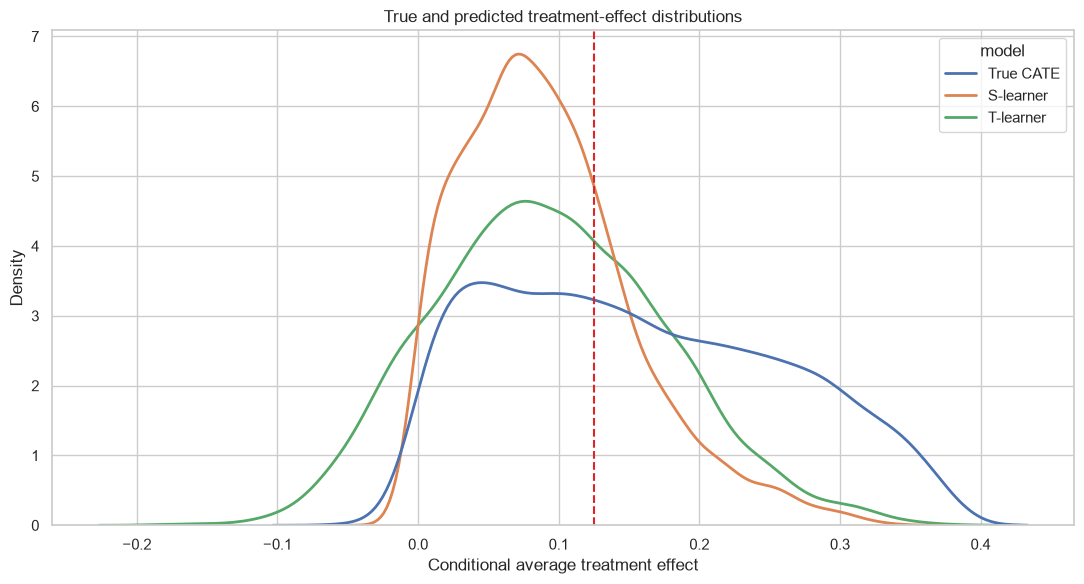

In [10]:
cate_distribution = pd.DataFrame(
    {
        "True CATE": true_cate,
        "S-learner": s_cate,
        "T-learner": t_cate,
    }
).melt(
    var_name="model",
    value_name="cate",
)

fig, axis = plt.subplots(
    figsize=(11, 6)
)

sns.kdeplot(
    data=cate_distribution,
    x="cate",
    hue="model",
    fill=False,
    common_norm=False,
    linewidth=2,
    ax=axis,
)

axis.axvline(
    TREATMENT_COST / RETENTION_VALUE,
    color="#DC2626",
    linestyle="--",
    label="Profitability threshold",
)

axis.set(
    title=(
        "True and predicted treatment-effect "
        "distributions"
    ),
    xlabel="Conditional average treatment effect",
    ylabel="Density",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "meta_learner_cate_distributions.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

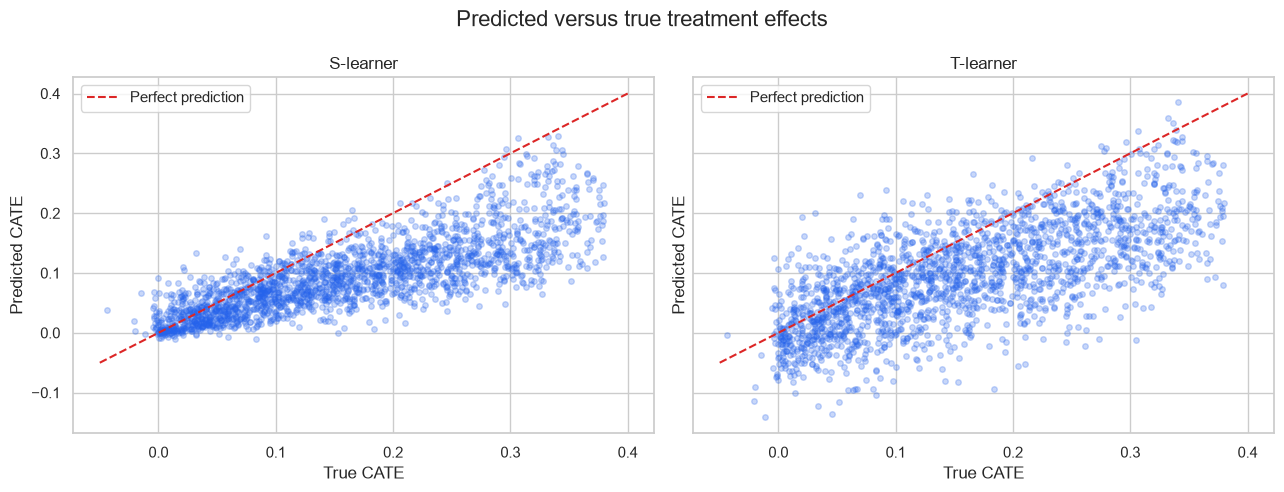

In [11]:
plot_rng = np.random.default_rng(
    RANDOM_SEED
)

sample_indices = plot_rng.choice(
    len(evaluation_data),
    size=2_000,
    replace=False,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    sharex=True,
    sharey=True,
)

model_predictions = {
    "S-learner": s_cate,
    "T-learner": t_cate,
}

for axis, (
    model_name,
    predictions,
) in zip(
    axes,
    model_predictions.items(),
):
    axis.scatter(
        true_cate[sample_indices],
        predictions[sample_indices],
        alpha=0.25,
        s=16,
        color="#2563EB",
    )

    axis.plot(
        [-0.05, 0.40],
        [-0.05, 0.40],
        color="#DC2626",
        linestyle="--",
        label="Perfect prediction",
    )

    axis.set(
        title=model_name,
        xlabel="True CATE",
        ylabel="Predicted CATE",
    )

    axis.legend()

fig.suptitle(
    "Predicted versus true treatment effects",
    fontsize=16,
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "meta_learner_cate_scatter.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [12]:
def create_cate_calibration(
    model_name: str,
    predicted_cate: np.ndarray,
    true_cate: np.ndarray,
    number_of_groups: int = 10,
) -> pd.DataFrame:
    calibration_data = pd.DataFrame(
        {
            "predicted_cate": predicted_cate,
            "true_cate": true_cate,
        }
    )

    calibration_data["group"] = pd.qcut(
        calibration_data["predicted_cate"],
        q=number_of_groups,
        duplicates="drop",
    )

    calibration_table = (
        calibration_data
        .groupby(
            "group",
            observed=True,
        )
        .agg(
            predicted_cate=(
                "predicted_cate",
                "mean",
            ),
            true_cate=(
                "true_cate",
                "mean",
            ),
            customers=(
                "true_cate",
                "size",
            ),
        )
        .reset_index(drop=True)
    )

    calibration_table["model"] = (
        model_name
    )

    calibration_table["rank"] = (
        np.arange(
            1,
            len(calibration_table) + 1,
        )
    )

    return calibration_table


calibration_results = pd.concat(
    [
        create_cate_calibration(
            "S-learner",
            s_cate,
            true_cate,
        ),
        create_cate_calibration(
            "T-learner",
            t_cate,
            true_cate,
        ),
    ],
    ignore_index=True,
)

display(calibration_results)

,predicted_cate,true_cate,customers,model,rank
0,0.0069,0.0279,600,S-learner,1
1,0.0277,0.0603,600,S-learner,2
2,0.0458,0.0894,600,S-learner,3
3,0.0621,0.1160,600,S-learner,4
4,0.0764,0.1414,600,S-learner,5
5,0.0916,0.1685,600,S-learner,6
6,0.1080,0.1994,600,S-learner,7
7,0.1265,0.2152,600,S-learner,8
8,0.1535,0.2474,600,S-learner,9
9,0.2195,0.2969,600,S-learner,10


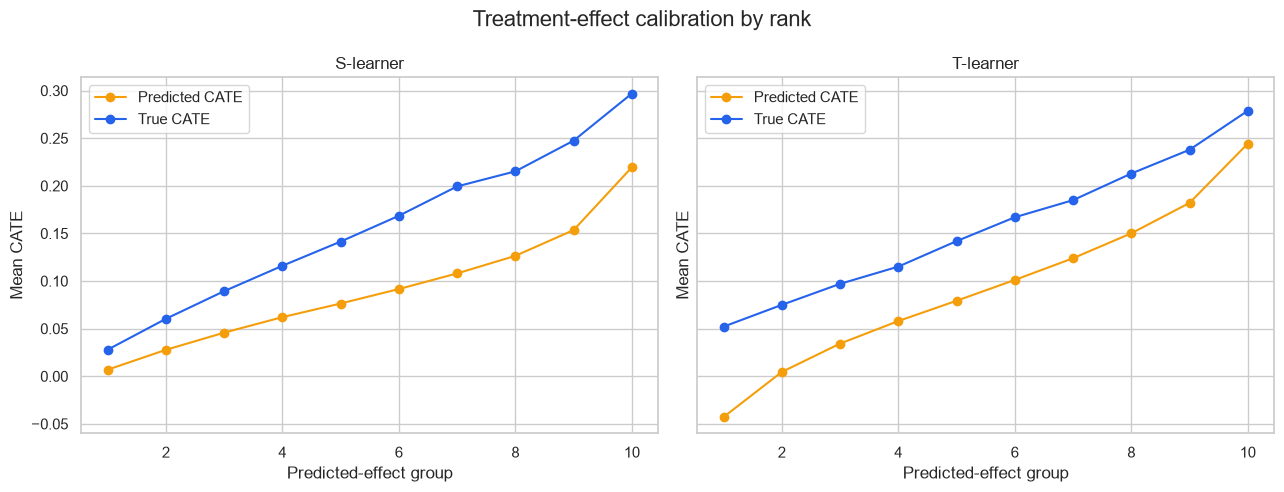

In [13]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    sharey=True,
)

for axis, model_name in zip(
    axes,
    ["S-learner", "T-learner"],
):
    model_calibration = calibration_results[
        calibration_results["model"]
        == model_name
    ]

    axis.plot(
        model_calibration["rank"],
        model_calibration["predicted_cate"],
        marker="o",
        label="Predicted CATE",
        color="#F59E0B",
    )

    axis.plot(
        model_calibration["rank"],
        model_calibration["true_cate"],
        marker="o",
        label="True CATE",
        color="#2563EB",
    )

    axis.set(
        title=model_name,
        xlabel="Predicted-effect group",
        ylabel="Mean CATE",
    )

    axis.legend()

fig.suptitle(
    "Treatment-effect calibration by rank",
    fontsize=16,
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "meta_learner_cate_calibration.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

## 5. Convert treatment-effect estimates into policies

For each customer, predicted incremental value is:

Predicted incremental value = 80 × predicted CATE − 10

A customer is treated only if:

1. predicted incremental value is positive; and
2. campaign capacity has not been exhausted.

The policy may therefore treat fewer than 20% when a model predicts that fewer
customers are profitable.

In [14]:
s_incremental_value = (
    RETENTION_VALUE * s_cate
    - TREATMENT_COST
)

t_incremental_value = (
    RETENTION_VALUE * t_cate
    - TREATMENT_COST
)

policy_decisions = {
    "Treat nobody": treat_none_policy(
        len(evaluation_data)
    ),
    "Random 20%": random_policy(
        population_size=len(evaluation_data),
        capacity=POLICY_CAPACITY,
        seed=RANDOM_SEED,
    ),
    "S-learner policy": top_score_policy(
        scores=s_incremental_value,
        capacity=POLICY_CAPACITY,
        require_positive=True,
    ),
    "T-learner policy": top_score_policy(
        scores=t_incremental_value,
        capacity=POLICY_CAPACITY,
        require_positive=True,
    ),
    "Oracle 20%": oracle_policy(
        data=evaluation_data,
        capacity=POLICY_CAPACITY,
        retention_value=RETENTION_VALUE,
        treatment_cost=TREATMENT_COST,
    ),
}

decision_summary = pd.DataFrame(
    {
        policy_name: {
            "treated_count": int(
                decisions.sum()
            ),
            "treatment_rate": float(
                decisions.mean()
            ),
        }
        for policy_name, decisions
        in policy_decisions.items()
    }
).T

display(decision_summary)

,treated_count,treatment_rate
Treat nobody,0.0000,0.0000
Random 20%,"1,200.0000",0.2000
S-learner policy,"1,200.0000",0.2000
T-learner policy,"1,200.0000",0.2000
Oracle 20%,"1,200.0000",0.2000


In [15]:
policy_results = []

for policy_name, decisions in (
    policy_decisions.items()
):
    result = evaluate_policy(
        data=evaluation_data,
        decisions=decisions,
        policy_name=policy_name,
        capacity=POLICY_CAPACITY,
        retention_value=RETENTION_VALUE,
        treatment_cost=TREATMENT_COST,
    )

    policy_results.append(result)

policy_results = pd.DataFrame(
    policy_results
)

oracle_profit = policy_results.loc[
    policy_results["policy"]
    == "Oracle 20%",
    "incremental_profit",
].iloc[0]

policy_results["regret_vs_oracle"] = (
    oracle_profit
    - policy_results["incremental_profit"]
)

policy_results[
    "oracle_profit_captured"
] = np.where(
    oracle_profit > 0,
    (
        policy_results["incremental_profit"]
        / oracle_profit
    ),
    np.nan,
)

policy_results = (
    policy_results
    .sort_values(
        "incremental_profit",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    policy_results[
        [
            "policy",
            "treated_count",
            "treatment_rate",
            "mean_cate_treated",
            "incremental_retained_customers",
            "incremental_profit",
            "profit_per_treated_customer",
            "regret_vs_oracle",
            "oracle_profit_captured",
        ]
    ]
)

,policy,treated_count,treatment_rate,mean_cate_treated,incremental_retained_customers,incremental_profit,profit_per_treated_customer,regret_vs_oracle,oracle_profit_captured
0,Oracle 20%,1200,0.2000,0.3079,369.4529,"17,556.2281",14.6302,0.0000,1.0000
1,S-learner policy,1200,0.2000,0.2722,326.6354,"14,130.8345",11.7757,"3,425.3936",0.8049
2,T-learner policy,1200,0.2000,0.2583,309.9819,"12,798.5555",10.6655,"4,757.6726",0.7290
3,Random 20%,1200,0.2000,0.1574,188.8243,"3,105.9408",2.5883,"14,450.2873",0.1769
4,Treat nobody,0,0.0000,0.0000,0.0000,0.0000,0.0000,"17,556.2281",0.0000


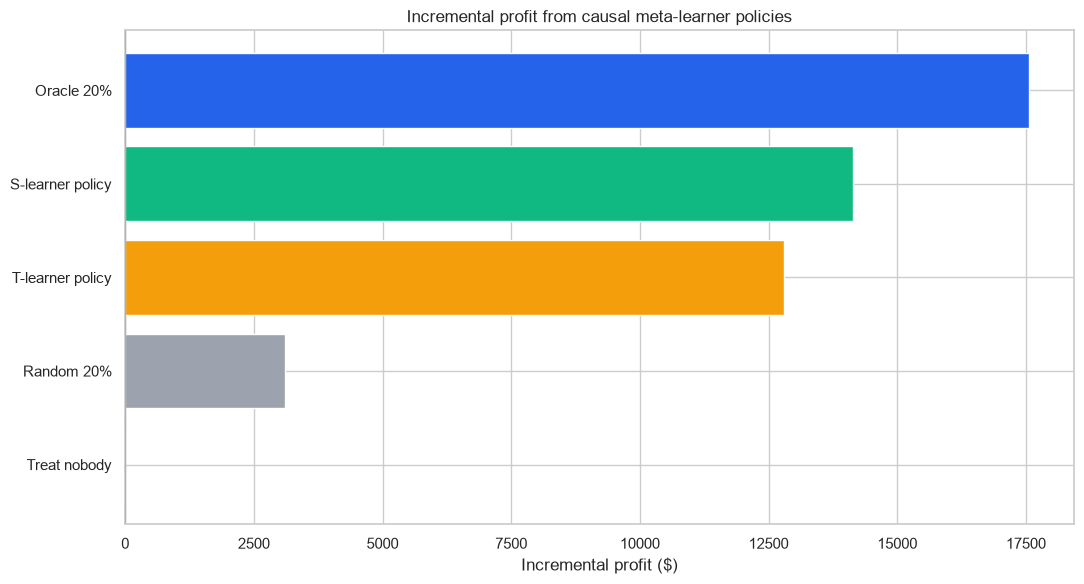

In [16]:
plot_data = policy_results.sort_values(
    "incremental_profit"
)

policy_colors = {
    "Treat nobody": "#6B7280",
    "Random 20%": "#9CA3AF",
    "S-learner policy": "#10B981",
    "T-learner policy": "#F59E0B",
    "Oracle 20%": "#2563EB",
}

fig, axis = plt.subplots(
    figsize=(11, 6)
)

axis.barh(
    plot_data["policy"],
    plot_data["incremental_profit"],
    color=[
        policy_colors[policy]
        for policy in plot_data["policy"]
    ],
)

axis.axvline(
    0,
    color="black",
    linewidth=0.8,
)

axis.set(
    title=(
        "Incremental profit from "
        "causal meta-learner policies"
    ),
    xlabel="Incremental profit ($)",
    ylabel="",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "meta_learner_policy_profit.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [17]:
stage_5_checks = {
    "training and evaluation sets disjoint": (
        set(training_data["customer_id"])
        .isdisjoint(
            set(
                evaluation_data[
                    "customer_id"
                ]
            )
        )
    ),
    "oracle columns excluded": (
        not set(MODEL_FEATURES)
        .intersection(
            FORBIDDEN_FEATURES
        )
    ),
    "S-learner CATE finite": (
        np.isfinite(s_cate).all()
    ),
    "T-learner CATE finite": (
        np.isfinite(t_cate).all()
    ),
    "S-learner respects capacity": (
        policy_decisions[
            "S-learner policy"
        ].mean()
        <= POLICY_CAPACITY
    ),
    "T-learner respects capacity": (
        policy_decisions[
            "T-learner policy"
        ].mean()
        <= POLICY_CAPACITY
    ),
    "oracle profit at least S-learner": (
        oracle_profit
        >= policy_results.loc[
            policy_results["policy"]
            == "S-learner policy",
            "incremental_profit",
        ].iloc[0]
    ),
    "oracle profit at least T-learner": (
        oracle_profit
        >= policy_results.loc[
            policy_results["policy"]
            == "T-learner policy",
            "incremental_profit",
        ].iloc[0]
    ),
}

stage_5_check_table = pd.DataFrame(
    {
        "criterion": stage_5_checks.keys(),
        "passed": stage_5_checks.values(),
    }
)

display(stage_5_check_table)

assert stage_5_check_table[
    "passed"
].all()

print("Stage 5 meta-learner checks passed.")

,criterion,passed
0,training and evaluation sets disjoint,True
1,oracle columns excluded,True
2,S-learner CATE finite,True
3,T-learner CATE finite,True
4,S-learner respects capacity,True
5,T-learner respects capacity,True
6,oracle profit at least S-learner,True
7,oracle profit at least T-learner,True


Stage 5 meta-learner checks passed.


## Interpretation

The S-learner and T-learner estimate heterogeneous treatment effects using only
observed treatment assignments, outcomes, and pre-treatment customer features.

The evaluation distinguishes two forms of performance:

1. **Effect-estimation performance**
   - ATE error
   - PEHE
   - CATE MAE
   - CATE correlation

2. **Decision performance**
   - Incremental retained customers
   - Incremental profit
   - Regret relative to the oracle
   - Percentage of oracle profit captured

A model with a lower PEHE does not necessarily produce the highest-profit
policy. Policy quality depends especially on whether the model correctly ranks
customers near the campaign-capacity cutoff.

The oracle policy remains an unattainable upper bound because it uses the
simulator's true treatment effects.